#Solução do Problema: Diagnóstico de Diabetes com Árvore de Decisão

**Etapa 1: Importações necessárias**

In [1]:
# Etapa 1: Importações necessárias

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Etapa 2: Carregar os dados

df=pd.read_csv('/content/diabetes_data.csv')
display(df)


,Age,BMI,Glucose Level,Family History,Diabetes
0,58,36.4,182,1,0
1,71,25.1,125,1,0
2,48,22.1,186,0,0
3,34,18.9,127,0,0
4,62,31.0,113,0,0
...,...,...,...,...,...
295,25,20.6,194,1,1
296,41,32.3,166,0,0
297,30,34.4,92,0,1
298,67,30.8,132,1,1


**Pré-processamento dos Dados**

              Age         BMI  Glucose Level  Family History    Diabetes
count  300.000000  300.000000     300.000000      300.000000  300.000000
mean    49.930000   29.099333     132.113333        0.476667    0.436667
std     17.793081    6.556786      37.478919        0.500290    0.496801
min     20.000000   18.100000      70.000000        0.000000    0.000000
25%     34.000000   23.475000     101.000000        0.000000    0.000000
50%     51.000000   29.800000     131.000000        0.000000    0.000000
75%     64.000000   34.600000     164.000000        1.000000    1.000000
max     79.000000   39.800000     199.000000        1.000000    1.000000


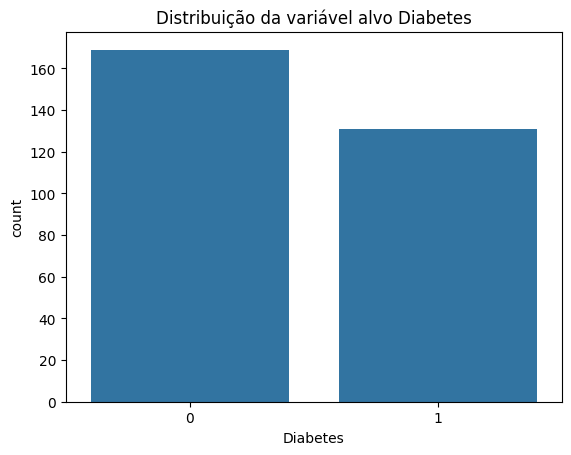

In [2]:
# Verificar valores nulos

df.isnull().sum()

# Como não há valores nulos neste caso fictício, seguimos com a análise

# Estatísticas básicas

print(df.describe())

# Visualizar a distribuição da variável alvo

sns.countplot(data=df, x='Diabetes')
plt.title('Distribuição da variável alvo Diabetes')
plt.show()


**Divisão de Dados e Treinamento**

In [3]:
# Separar os dados em recursos (X) e variável alvo (y)
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']


# Dividir os dados em conjuntos de treinamento e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo de Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

# Avaliar o modelo
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**Análise dos Resultados**


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.69      0.66        36
           1       0.45      0.38      0.41        24

    accuracy                           0.57        60
   macro avg       0.54      0.53      0.53        60
weighted avg       0.55      0.57      0.56        60



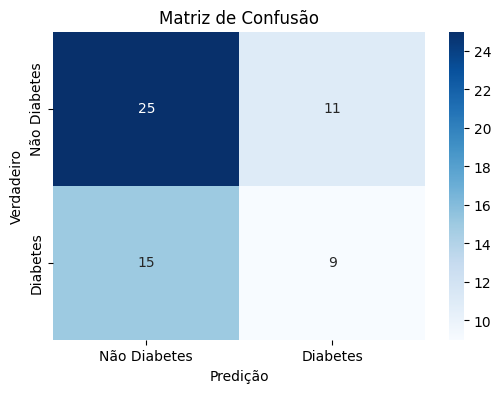

Acurácia do modelo: 0.5667


In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Diabetes', 'Diabetes'], yticklabels=['Não Diabetes', 'Diabetes'])
plt.title('Matriz de Confusão')
plt.xlabel('Predição')
plt.ylabel('Verdadeiro')
plt.show()


accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {accuracy:.4f}')


**Visualização da Árvore de Decisão**

In [7]:
def predict_diabetes(Age, BMI, Glucose_Level, Family_History): # Changed the input parameters to match the training data columns
    """
    Predicts the likelihood of diabetes based on input features.
    """
    # Create a DataFrame from the input features using the correct column names
    input_data = pd.DataFrame({
        'Age': [Age],
        'BMI': [BMI],
        'Glucose Level': [Glucose_Level],  # Using the correct column name
        'Family History': [Family_History]  # Using the correct column name
    })

    # Make the prediction
    prediction = model.predict(input_data)[0]

    if prediction == 1:
        return "A pessoa tem probabilidade de ter diabetes."
    else:
        return "A pessoa tem baixa probabilidade de ter diabetes."


# Example usage (replace with user input) - Adjusted to use the correct column names
Age = 70 #@param {type:"number"}
BMI = 33.6 #@param {type:"number"}
Glucose_Level = 130 #@param {type:"number"}  # Using Glucose Level instead of Glucose
Family_History = 1  #@param {type:"number"}  # Assuming a binary value (0 or 1) for Family History

result = predict_diabetes(Age, BMI, Glucose_Level, Family_History) # Calling the function with the correct arguments
result

'A pessoa tem baixa probabilidade de ter diabetes.'